In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

### Load Data

In [2]:
def generate_data(n, r=0):
    n_per_class = n // 3
    x1_0 = np.random.normal(-2, 1, n_per_class)
    x2_0 = np.random.normal(0, 1, n_per_class)
    x1_1 = np.random.normal(2, 1, n_per_class)
    x2_1 = np.random.normal(0, 1, n_per_class)
    x1_2 = np.random.normal(0, 1, n_per_class)
    x2_2 = np.random.normal(3, 1, n_per_class)
    x1 = np.concatenate([x1_0, x1_1, x1_2])
    x2 = np.concatenate([x2_0, x2_1, x2_2])
    y = np.concatenate([np.zeros(n_per_class, dtype=int), np.ones(n_per_class, dtype=int),
                        np.full(n_per_class, 2, dtype=int)])
    if r:
        idx = np.random.choice(len(y), size=min(r, len(y)), replace=False)
        for i in idx:
            classes = [0, 1, 2]
            classes.remove(y[i])
            y[i] = np.random.choice(classes)

    %matplotlib widget
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x1[y == 0], x2[y == 0], y[y == 0], label="Class 0", color="red")
    ax.scatter(x1[y == 1], x2[y == 1], y[y == 1], label="Class 1", color="green")
    ax.scatter(x1[y == 2], x2[y == 2], y[y == 2], label="Class 2", color="blue")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("y")
    ax.set_zticks([0, 1, 2])
    ax.legend()
    plt.show()
    return x1, x2, y

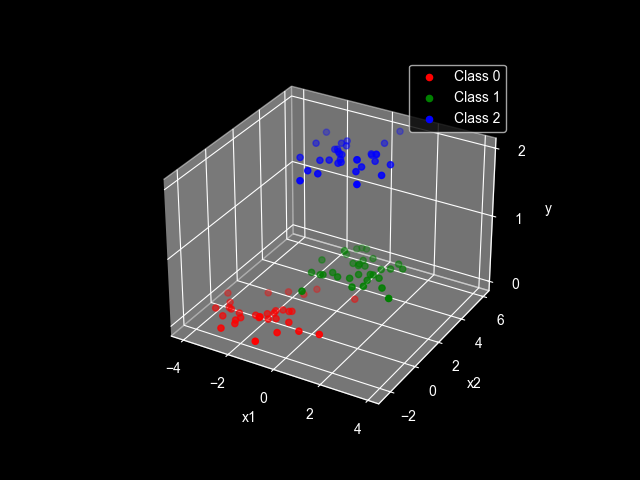

In [3]:
X11, X12, y1 = generate_data(100)

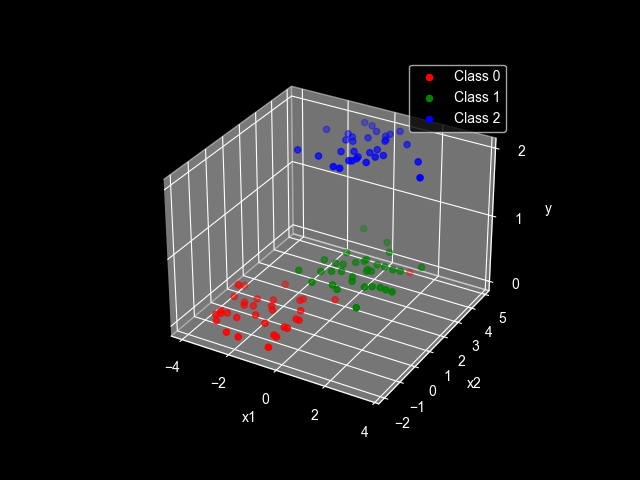

In [4]:
X21, X22, y2 = generate_data(100, r = 1)

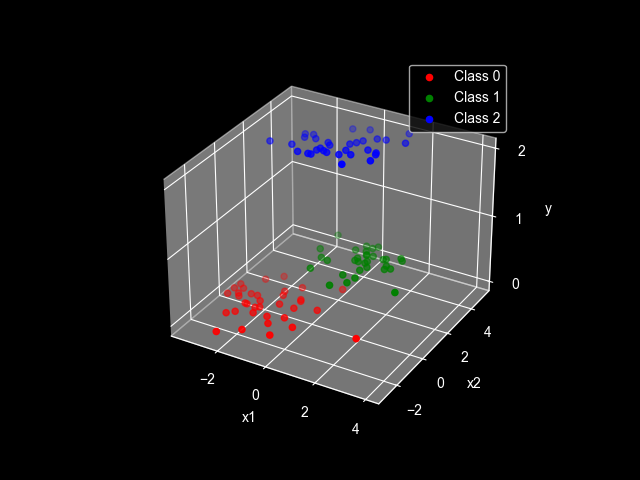

In [5]:
X31, X32, y3 = generate_data(100, r=2)

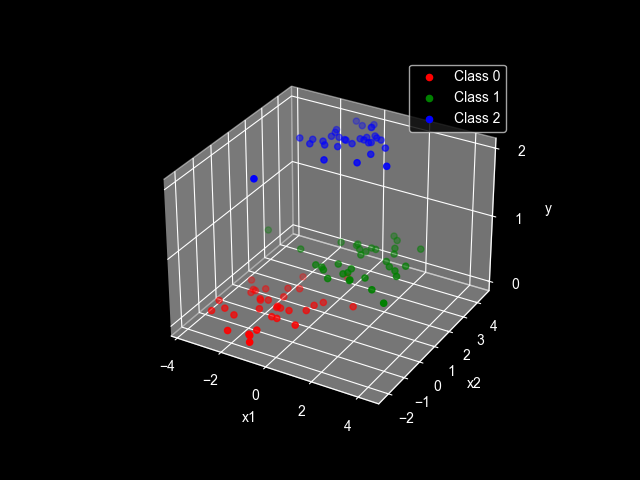

In [6]:
X41, X42, y4 = generate_data(100, r=5)

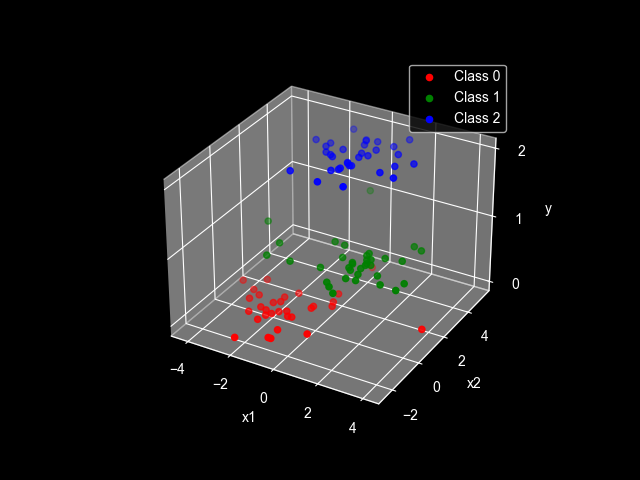

In [7]:
X51, X52, y5 = generate_data(100, r=10)

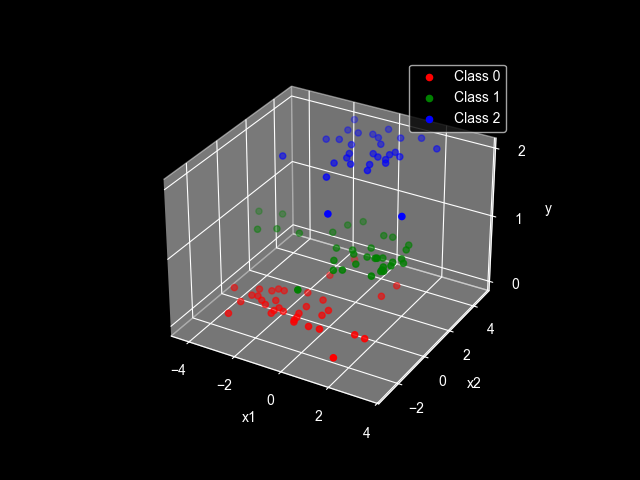

In [8]:
X61, X62, y6 = generate_data(100, r=20)

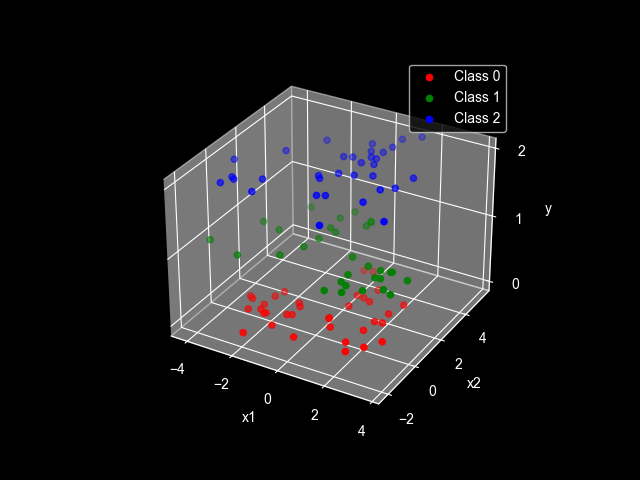

In [9]:
X71, X72, y7 = generate_data(100, r=50)

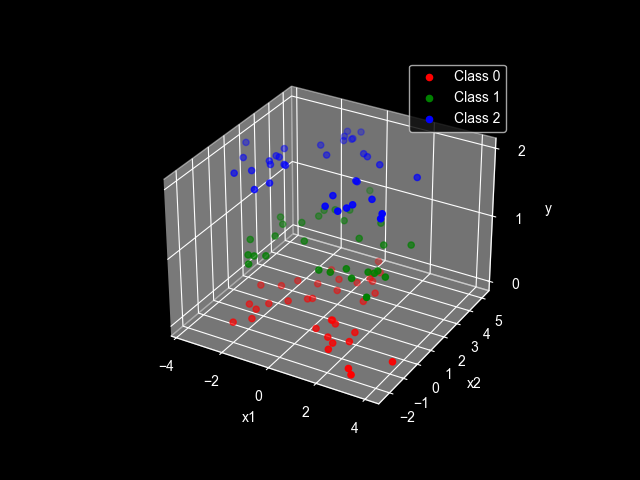

In [10]:
X81, X82, y8 = generate_data(100, r=70)

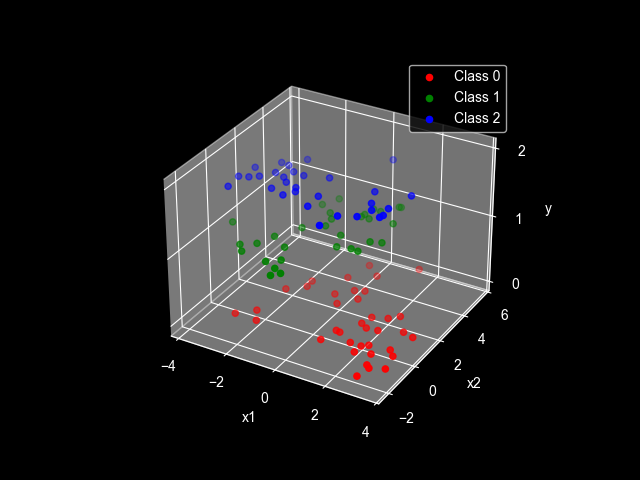

In [11]:
X91, X92, y9 = generate_data(100, r=90)

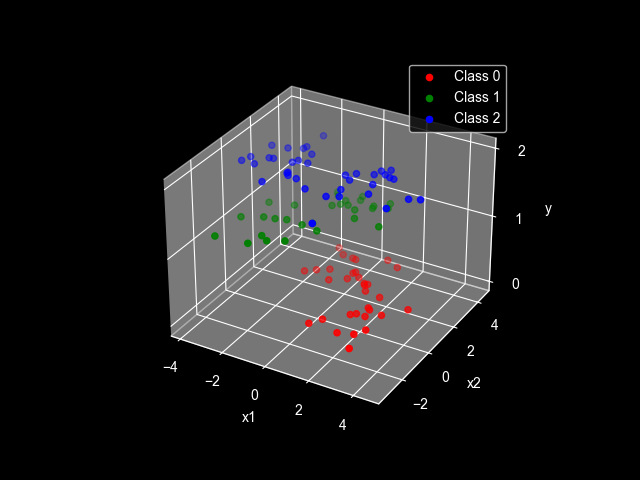

In [12]:
X101, X102, y10 = generate_data(100, r=100)

### Utils

In [13]:
import math
def softmax(z):
    exp_z = []
    for value in z:
        exp_z.append(math.exp(value))
    total = sum(exp_z)
    probabilities = []
    for value in exp_z:
        probabilities.append(value / total)
    return probabilities

In [14]:
def predict(x1, x2, weights, biases):
    probabilities = []
    for i in range(len(x1)):
        z0 = (weights[0][0] * x1[i] + weights[0][1] * x2[i] + biases[0])
        z1 = (weights[1][0] * x1[i] + weights[1][1] * x2[i] + biases[1])
        z2 = (weights[2][0] * x1[i] + weights[2][1] * x2[i] + biases[2])
        p = softmax([z0, z1, z2])
        probabilities.append(p)
    return probabilities

In [15]:
def predict_class(probabilities):
    predictions = []
    for p in probabilities:
        prediction = p.index(max(p))
        predictions.append(prediction)

    return predictions

In [16]:
def cross_entropy(y, y_pred): # Cross Entropy, Log Loss, Logistic Loss, Negative Log-Likelihood, etc
    total_loss = 0
    for i in range(len(y)):
        true_class = y[i]
        probability = probabilities[i][true_class]
        loss = -math.log(probability)
        total_loss += loss
    return total_loss / len(y)

In [17]:
def derivative_loss(X, y, p):
    m = len(y)
    return (X.T @ (p - y)) / m

In [18]:
def confusion_matrix(y, y_pred):
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for i, j in zip(y, y_pred):
        if i == 0 and i == j:
            TN += 1
        elif i == 1 and i == j:
            TP += 1
        elif i == 0 and i!=j:
            FP += 1
        elif i == 1 and i!=j:
            FN += 1
    return TP, TN, FP, FN

In [19]:
def Accuracy(y, y_pred):
    TP, TN, FP, FN = confusion_matrix(y, y_pred)
    if len(y) == 0:
        return 0
    acc = (TP + TN) / (TP + TN + FP + FN)
    return round(acc, 4)

In [20]:
def ErrorRate(y, y_pred):
    er = 1- Accuracy(y, y_pred)
    return round(er, 4)

In [21]:
def Precision(y, y_pred):
    TP, TN, FP, FN = confusion_matrix(y, y_pred)
    if TP + FP == 0:
        return 0
    p = TP / (TP + FP)
    return round(p, 4)

In [22]:
def TPR(y, y_pred): # Recall, Sensitivity, True Positive Rate (TPR)
    TP, TN, FP, FN = confusion_matrix(y, y_pred)
    if TP + FN == 0:
        return 0
    tpr = TP / (TP + FN)
    return round(tpr, 4)

In [23]:
def TNR(y, y_pred): # Specificity, True Negative Rate (TNR)
    TP, TN, FP, FN = confusion_matrix(y, y_pred)
    if TN + FP == 0 :
        return 0
    tnr = TN / (TN + FP)
    return round(tnr, 4)

In [24]:
def FPR(y, y_pred): # Fallout, False Positive Rate (FPR) = 1 - TNR
    fpr = 1 - TNR(y, y_pred)
    return round(fpr, 4)

In [25]:
def FNR(y, y_pred): # False Negative Rate (FNR) = 1 - TPR
    fnr = 1 - TPR(y, y_pred)
    return round(fnr, 4)

In [26]:
def F1Score(y, y_pred):
    p = Precision(y, y_pred)
    r = TPR(y, y_pred)
    if p+r == 0:
        return 0
    f1 = (2*p*r)/(p+r)
    return round(f1, 4)

In [27]:
def plot(x1, x2, y, weights, biases):

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    # Actual data

    ax.scatter(
        x1[y == 0],
        x2[y == 0],
        y[y == 0],
        label="Class 0",
        color="red"
    )

    ax.scatter(
        x1[y == 1],
        x2[y == 1],
        y[y == 1],
        label="Class 1",
        color="green"
    )

    ax.scatter(
        x1[y == 2],
        x2[y == 2],
        y[y == 2],
        label="Class 2",
        color="blue"
    )

    # Prediction grid

    x1_min = min(x1)
    x1_max = max(x1)

    x2_min = min(x2)
    x2_max = max(x2)

    step = 0.1

    x1_grid = []
    x2_grid = []
    y_grid = []

    current_x1 = x1_min

    while current_x1 <= x1_max:

        current_x2 = x2_min

        while current_x2 <= x2_max:

            probabilities = predict(
                [current_x1],
                [current_x2],
                weights,
                biases
            )

            prediction = predict_class(probabilities)[0]

            x1_grid.append(current_x1)
            x2_grid.append(current_x2)
            y_grid.append(prediction)

            current_x2 += step

        current_x1 += step

    # Predicted classification regions

    ax.scatter(
        x1_grid,
        x2_grid,
        y_grid,
        alpha=0.05
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("Class")

    ax.set_zticks([0, 1, 2])

    ax.legend()

    plt.show()

### Solve by Newton-Raphson Method

In [30]:
def solve_by_newton(x, y, n_epochs=20):
    c = 0
    m = 0
    n = len(y)
    for _ in range(n_epochs):
        p = [sigmoid(x[i] * m + c) for i in range(n)]
        dc = sum(p[i] - y[i] for i in range(n)) / n # dL/dc
        dm = sum((p[i] - y[i]) * x[i] for i in range(n)) / n # dL/dm
        h_cc = sum(p[i] * (1 - p[i]) for i in range(n)) / n
        h_cm = sum(p[i] * (1 - p[i]) * x[i] for i in range(n)) / n
        h_mm = sum(p[i] * (1 - p[i]) * x[i] ** 2 for i in range(n)) / n
        det = h_cc * h_mm - h_cm ** 2
        delta_c = (h_mm * dc - h_cm * dm) / det
        delta_m = (-h_cm * dc + h_cc * dm) / det
        c -= delta_c
        m -= delta_m
    y_pred = [predict(xi, m, c) for xi in x]
    acc = Accuracy(y, y_pred)
    f1 = F1Score(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4),
          "  Accuracy :", acc, "  F1-Score :", f1, )
    plot(x, y, m, c)

In [31]:
# Solve for Data 1
solve_by_newton(X1, y1)

NameError: name 'X1' is not defined

In [ ]:
# Solve for Data 2
solve_by_newton(X2, y2)

In [ ]:
# Solve for Data 3
solve_by_newton(X3, y3)

In [ ]:
# Solve for Data 4
solve_by_newton(X4, y4)

In [ ]:
# Solve for Data 5
solve_by_newton(X5, y5)

In [ ]:
# Solve for Data 5
solve_by_newton(X5, y5)

In [ ]:
# Solve for Data 6
solve_by_newton(X6, y6)

In [ ]:
# Solve for Data 7
solve_by_newton(X7, y7)

In [ ]:
# Solve for Data 8
solve_by_newton(X8, y8)

In [ ]:
# Solve for Data 9
solve_by_newton(X9, y9)

In [ ]:
# Solve for Data 10
solve_by_newton(X10, y10)

In [ ]:
# Solve for Data 11
solve_by_newton(X11, y11)

In [ ]:
# Solve for Data 12
solve_by_newton(X12, y12)

In [ ]:
# Solve for Data 13
solve_by_newton(X13, y13)

In [ ]:
# Solve for Data 14
solve_by_newton(X14, y14)

### Solve by Grid Search

In [ ]:
def solve_by_grid_search(x, y, m_range=(-100, 100), c_range=(-100, 100), step=0.1):
    best_loss = float("inf")
    best_m = None
    best_c = None
    for ma in range(m_range[0], m_range[1]):
        m = ma*step
        for ca in range(c_range[0], c_range[1]):
            c = ca*step
            y_pred = [sigmoid(xi * m + c) for xi in x]
            loss = log_loss(y, y_pred)
            if loss < best_loss:
                best_loss = loss
                best_m = m
                best_c = c
    y_pred = [predict(xi, best_m, best_c) for xi in x]
    acc = Accuracy(y, y_pred)
    f1 = F1Score(y, y_pred)
    print(f"Slope :", round(best_m, 4), "  y-Intercept :", round(best_c, 4),
          "  Accuracy :", acc, "  F1-Score :", f1, )
    plot(x, y, best_m, best_c)

In [ ]:
# Solve for Data 1
solve_by_grid_search(X1, y1)

In [ ]:
# Solve for Data 2
solve_by_grid_search(X2, y2)

In [ ]:
# Solve for Data 3
solve_by_grid_search(X3, y3)

In [ ]:
# Solve for Data 4
solve_by_grid_search(X4, y4)

In [ ]:
# Solve for Data 5
solve_by_grid_search(X5, y5)

In [ ]:
# Solve for Data 6
solve_by_grid_search(X6, y6)

In [ ]:
# Solve for Data 7
solve_by_grid_search(X7, y7)

In [ ]:
# Solve for Data 8
solve_by_grid_search(X8, y8)

In [ ]:
# Solve for Data 9
solve_by_grid_search(X9, y9)

In [ ]:
# Solve for Data 10
solve_by_grid_search(X10, y10)

In [ ]:
# Solve for Data 11
solve_by_grid_search(X11, y11)

In [ ]:
# Solve for Data 12
solve_by_grid_search(X12, y12)

In [ ]:
# Solve for Data 13
solve_by_grid_search(X13, y13)

In [ ]:
# Solve for Data 14
solve_by_grid_search(X14, y14)

### Solve by Gradient Descent

In [ ]:
def solve_by_grad_descent(x, y, n_epochs=10000, eta=0.1):
    c = 0
    m = 0
    n = len(y)
    for _ in range(n_epochs):
        y_pred = [sigmoid(m * x[i] + c) for i in range(n)]
        dc = sum(y_pred[i] - y[i] for i in range(n)) / n
        dm = sum((y_pred[i] - y[i]) * x[i] for i in range(n)) / n
        c -= eta * dc
        m -= eta * dm
    y_pred = [predict(xi, m, c) for xi in x]
    acc = Accuracy(y, y_pred)
    f1 = F1Score(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4),
          "  Accuracy :", acc, "  F1-Score :", f1, )
    plot(x, y, m, c)

In [ ]:
# Solve for Data 1
solve_by_grad_descent(X1, y1)

In [ ]:
# Solve for Data 2
solve_by_grad_descent(X2, y2)

In [ ]:
# Solve for Data 3
solve_by_grad_descent(X3, y3)

In [ ]:
# Solve for Data 4
solve_by_grad_descent(X4, y4)

In [ ]:
# Solve for Data 5
solve_by_grad_descent(X5, y5)

In [ ]:
# Solve for Data 6
solve_by_grad_descent(X6, y6)

In [ ]:
# Solve for Data 7
solve_by_grad_descent(X7, y7)

In [ ]:
# Solve for Data 8
solve_by_grad_descent(X8, y8)

In [ ]:
# Solve for Data 9
solve_by_grad_descent(X9, y9)

In [ ]:
# Solve for Data 10
solve_by_grad_descent(X10, y10)

In [ ]:
# Solve for Data 11
solve_by_grad_descent(X11, y11)

In [ ]:
# Solve for Data 12
solve_by_grad_descent(X12, y12)

In [ ]:
# Solve for Data 13
solve_by_grad_descent(X13, y13)

In [ ]:
# Solve for Data 14
solve_by_grad_descent(X14, y14)

### Solve by SkLearn

In [28]:
def get_model(X, y):
    model = LogisticRegression(random_state=42)
    model.fit(X, y)
    return model.intercept_.tolist(), model.coef_.tolist(), model

In [29]:
from sklearn.metrics import accuracy_score, f1_score

def solve_by_sklearn(x1, x2, y):
    x_b = np.array([x1, x2]).T
    c, *m, model = get_model(x_b, y)
    y_pred = model.predict(x_b)
    acc = accuracy_score(y, y_pred)
    #f1 = f1_score(y, y_pred)
    print(f"Slopes :", m[0], "  y-Intercept :", c,
          "  Accuracy :", acc)
    plot(x1, x2, y, m[0], c)

Slopes : [[-1.292433249438717, -0.4771919946634418], [1.5181837271150804, -0.680678635692198], [-0.22575047767636286, 1.1578706303556394]]   y-Intercept : [0.6067598432535322, 0.26940736348515704, -0.8761672067386878]   Accuracy : 0.9191919191919192


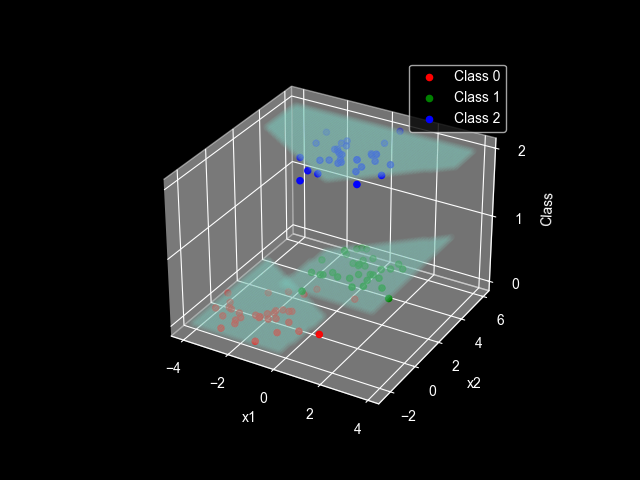

In [30]:
# Solve for Data 1
solve_by_sklearn(X11, X12, y1)

In [ ]:
# Solve for Data 2
solve_by_sklearn(X2, y2)

In [ ]:
# Solve for Data 3
solve_by_sklearn(X3, y3)

In [ ]:
# Solve for Data 4
solve_by_sklearn(X4, y4)

In [ ]:
# Solve for Data 5
solve_by_sklearn(X5, y5)

In [ ]:
# Solve for Data 6
solve_by_sklearn(X6, y6)

In [ ]:
# Solve for Data 7
solve_by_sklearn(X7, y7)

In [ ]:
# Solve for Data 8
solve_by_sklearn(X8, y8)

In [ ]:
# Solve for Data 9
solve_by_sklearn(X9, y9)

In [ ]:
# Solve for Data 10
solve_by_sklearn(X10, y10)

In [ ]:
# Solve for Data 11
solve_by_sklearn(X11, y11)

In [ ]:
# Solve for Data 12
solve_by_sklearn(X12, y12)

In [ ]:
# Solve for Data 13
solve_by_sklearn(X13, y13)

In [ ]:
# Solve for Data 14
solve_by_sklearn(X14, y14)

End